# Assignment 01 PCD (Downsampling and Upsampling)

### Nama: Jundan Saiful Haq
### NIM : 25/560768/PA/23633

# 1. Import Depedencies

In [67]:
from google.colab import drive
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#mount drive
drive.mount('/content/drive')

#config visuaisasi matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Crop center & grayscale

Saya memakai metode crop center untuk mem-fix kan ukuran citra pada tugas ini menjadi 256x256, dan kita menggunakan crop center agar tiap run notebook ini selalu konsisten memotong tengah citra kita. Dan fungsi grayscale ditambahkan itu untuk membuat 3 channel citra RGB menjadi 1 channel

Jika semisal input citra lebih kecil dari target_size, akan diterapkan scaling prorporsional terlebih dahulu.

In [68]:
def preprocess_image(img, target_size=256):
  if img is None:
    raise ValueError("tidak ada foto terddeteksi")

  if len(img.shape) == 3:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  else:
    img_gray = img.copy()

  h, w = img_gray.shape

  #normalisasi
  if h < target_size or w < target_size:
    scale = max(target_size / h, target_size / w)
    new_w, new_h = int(np.ceil(w * scale)), int(np.ceil(h * scale))
    img_gray = cv2.resize(img_gray, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    h, w = img_gray.shape

  #center crop
  start_y = (h - target_size) // 2
  start_x = (w - target_size) // 2
  cropped = img_gray[start_y : start_y + target_size, start_x : start_x + target_size]

  return cropped.astype(np.float64)

# 3. Load local image (via mount drive)

In [69]:
DRIVE_IMG_DIR = "/content/drive/MyDrive/Tugas/Ilmu_Komputer/Semester_3/PCD/Assignment01/images"

image_files = {
    "image1": os.path.join(DRIVE_IMG_DIR, "armadillo-0018.jpg"),
    "image2": os.path.join(DRIVE_IMG_DIR, "kangaroo-0008.jpg"),
    "image3": os.path.join(DRIVE_IMG_DIR, "polar_bear-0010.jpg"),
}

images = {}
for label, filepath in image_files.items():
  raw_img = cv2.imread(filepath)

  if raw_img is None:
    filename = os.path.basename(filepath)
    print(f"tidak ada gambar ditemukan")

    # fallback jika belum up foto
    dummy = np.zeros((300, 300, 3), dtype=np.uint8)
    if label == "image1":
      dummy = np.random.randint(0, 256, (300, 300, 3), dtype=np.uint8)
    elif label == "image2":
      cv2.rectangle(dummy, (50, 50), (250, 250), (255, 255, 255), 4)
      cv2.putText(dummy, "SHARP", (60, 160), cv2.FONT_HERSHEY_SIMPLEX, 1.6, (255, 255, 255), 4)
    else:
      grid = np.tile(np.linspace(0, 255, 300, dtype=np.uint8), (300, 1))
      dummy = cv2.merge([grid, grid, grid])
    raw_img = dummy
  else:
    print(f"foto berhasil dimuat dari: {os.path.basename(filepath)} ({raw_img.shape[1]}x{raw_img.shape[0]})")

  images[label] = preprocess_image(raw_img, target_size=256)

foto berhasil dimuat dari: armadillo-0018.jpg (256x256)
foto berhasil dimuat dari: kangaroo-0008.jpg (256x256)
foto berhasil dimuat dari: polar_bear-0010.jpg (256x256)


# 4. Downsampling algorithm

Menggunakan metode downsampling Max, Average, Median

In [70]:
def manual_downsampling(img, target_size, mode = 'avg'):
  h,w = img.shape
  assert h == w, "citra input harus berdimensi persegi"
  k = h // target_size
  output = np.zeros((target_size, target_size), dtype=np.float64)

  for i in range(target_size):
    for j in range(target_size):
      # ambil blok non overlapping k x k
      block = img[i * k : (i + 1) * k, j * k : (j + 1) * k]

      if mode == 'max':
        output[i, j] = np.max(block)
      elif mode == 'avg':
        output[i, j] = np.mean(block)
      elif mode == 'median':
        output[i, j] = np.median(block)
      else:
        raise ValueError("metode harus 'max', 'avg', atau 'median'")

  return output

# 5. Upsampling algorithm

Menggunakan metode nearest neighbor, bilinear, bicubic (yang bicubic menggunakan bobot interpolasi tetangga 1: 0.7, tetangga 2: 0.3)

In [71]:
def get_two_neighbors(coord, max_limit):
  n1 = int(round(coord))
  n1 = np.clip(n1, 0, max_limit - 1)

  # tentukan tetangga ke-2 berdasarkan posisi fraksional terhadap tetangga ke-1
  if coord >= n1:
    n2 = n1 + 1
  else:
    n2 = n1 - 1

  n2 = np.clip(n2, 0, max_limit - 1)
  return n1, n2

def manual_upsampling(img, target_size=256, method='bicubic'):
  h_in, w_in = img.shape
  h_out, w_out = target_size, target_size
  output = np.zeros((h_out, w_out), dtype=np.float64)

  scale_y = h_in / h_out
  scale_x = w_in / w_out

  if method == 'nn':
    #nnearest neighbor
    for i in range(h_out):
      src_y = min(int(round(i * scale_y)), h_in - 1)
      for j in range(w_out):
        src_x = min(int(round(j * scale_x)), w_in - 1)
        output[i, j] = img[src_y, src_x]

  elif method == 'bilinear':
    # bilinear
    for i in range(h_out):
      y = i * scale_y
      y1 = int(np.floor(y))
      y2 = min(y1 + 1, h_in - 1)
      dy = y - y1

      for j in range(w_out):
        x = j * scale_x
        x1 = int(np.floor(x))
        x2 = min(x1 + 1, w_in - 1)
        dx = x - x1

        # bobot fraksional bilinear
        w_tl = (1.0 - dx) * (1.0 - dy)
        w_tr = dx * (1.0 - dy)
        w_bl = (1.0 - dx) * dy
        w_br = dx * dy

        output[i, j] = (w_tl * img[y1, x1] +
                        w_tr * img[y1, x2] +
                        w_bl * img[y2, x1] +
                        w_br * img[y2, x2])

  elif method == 'bicubic':
    #bicubic dengan bobot tetangga 1: 0.7, tetangga 2: 0.3
    w1, w2 = 0.7, 0.3

    for i in range(h_out):
      y = i * scale_y
      y_n1, y_n2 = get_two_neighbors(y, h_in)

      for j in range(w_out):
        x = j * scale_x
        x_n1, x_n2 = get_two_neighbors(x, w_in)

        val = (
            (w1 * w1) * img[y_n1, x_n1] +
            (w1 * w2) * img[y_n1, x_n2] +
            (w2 * w1) * img[y_n2, x_n1] +
            (w2 * w2) * img[y_n2, x_n2]
        )
        output[i, j] = val

  else:
    raise ValueError("metode harus 'nn', 'bilinear', atau 'bicubic'")

  return np.clip(output, 0.0, 255.0)

# 6. Downsampling experiment

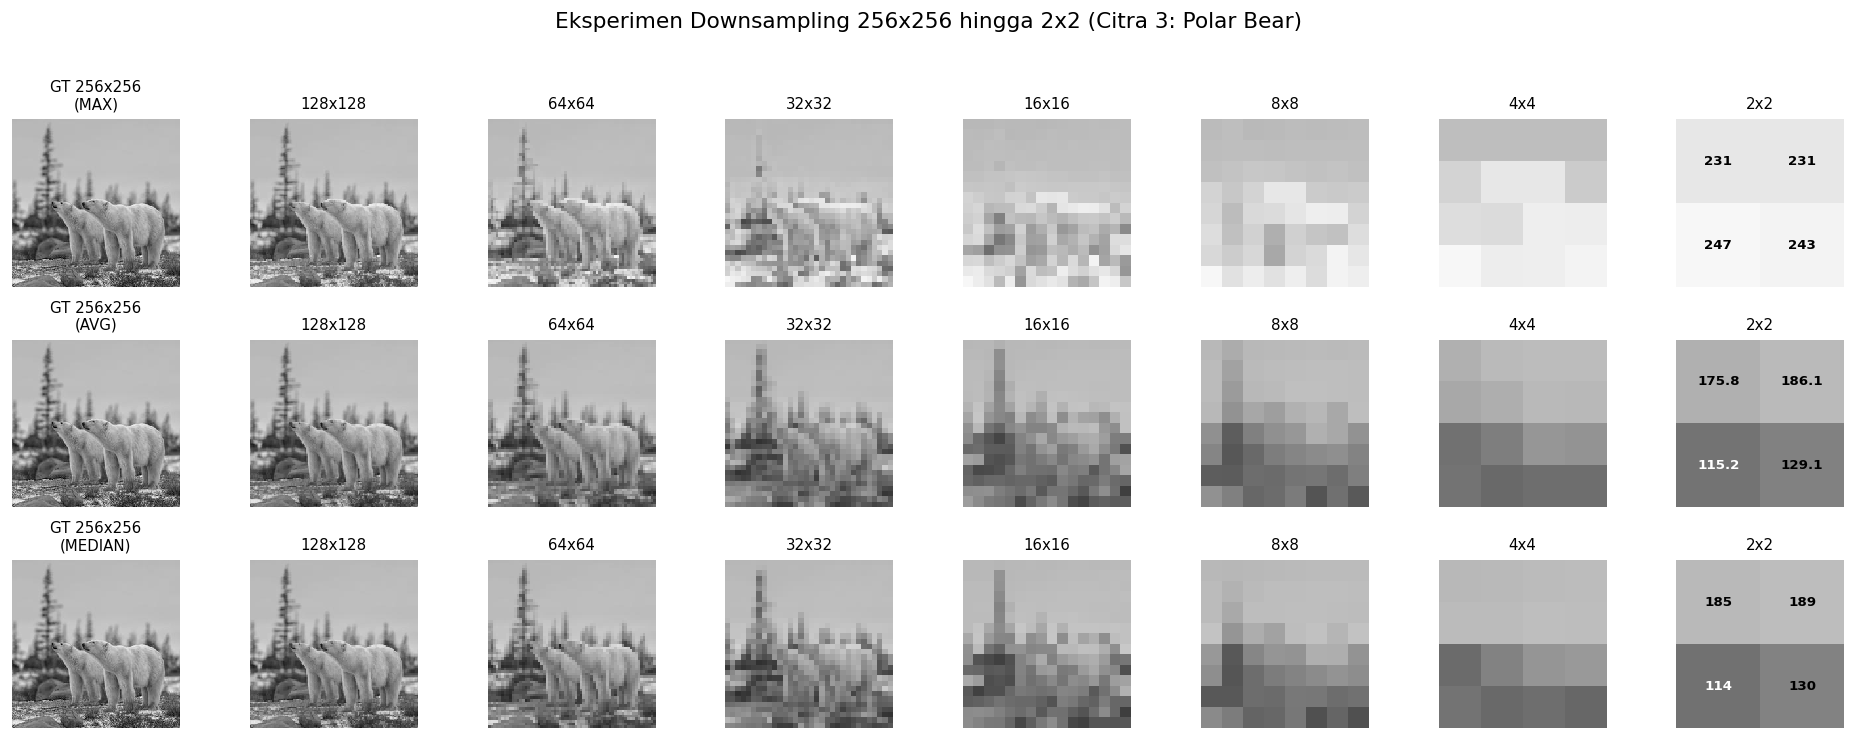

In [72]:
sample_img = images["image3"]
sizes = [128, 64, 32, 16, 8, 4, 2]
modes = ['max', 'avg', 'median']

fig, axes = plt.subplots(len(modes), len(sizes) + 1, figsize=(16, 6))

for row_idx, mode in enumerate(modes):
    #GT Acuan
    axes[row_idx, 0].imshow(sample_img, interpolation='nearest', vmin=0, vmax=255)
    axes[row_idx, 0].set_title(f"GT 256x256\n({mode.upper()})", fontsize=9)
    axes[row_idx, 0].axis('off')

    # penurunan frekuensi pencuplikan spasial
    for col_idx, sz in enumerate(sizes):
        down = manual_downsampling(sample_img, target_size=sz, mode=mode)
        ax = axes[row_idx, col_idx + 1]

        # vmin=0 dan vmax=255 agar warna putih/hitam absolut sesuai nilai piksel 8-bit
        ax.imshow(down, interpolation='nearest', vmin=0, vmax=255)
        ax.set_title(f"{sz}x{sz}", fontsize=9)
        ax.axis('off')

        if sz == 2:
            for r in range(2):
                for c in range(2):
                    val = down[r, c]
                    # 1 desimal untuk mode avg, bilangan bulat untuk max & median
                    val_str = f"{val:.1f}" if mode == 'avg' else f"{int(round(val))}"
                    # kontras adaptif
                    txt_color = "black" if val > 128 else "white"
                    ax.text(c, r, val_str, color=txt_color, fontsize=8,
                            ha='center', va='center', fontweight='bold')

plt.suptitle("Eksperimen Downsampling 256x256 hingga 2x2 (Citra 3: Polar Bear)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 7. Upsampling experiment

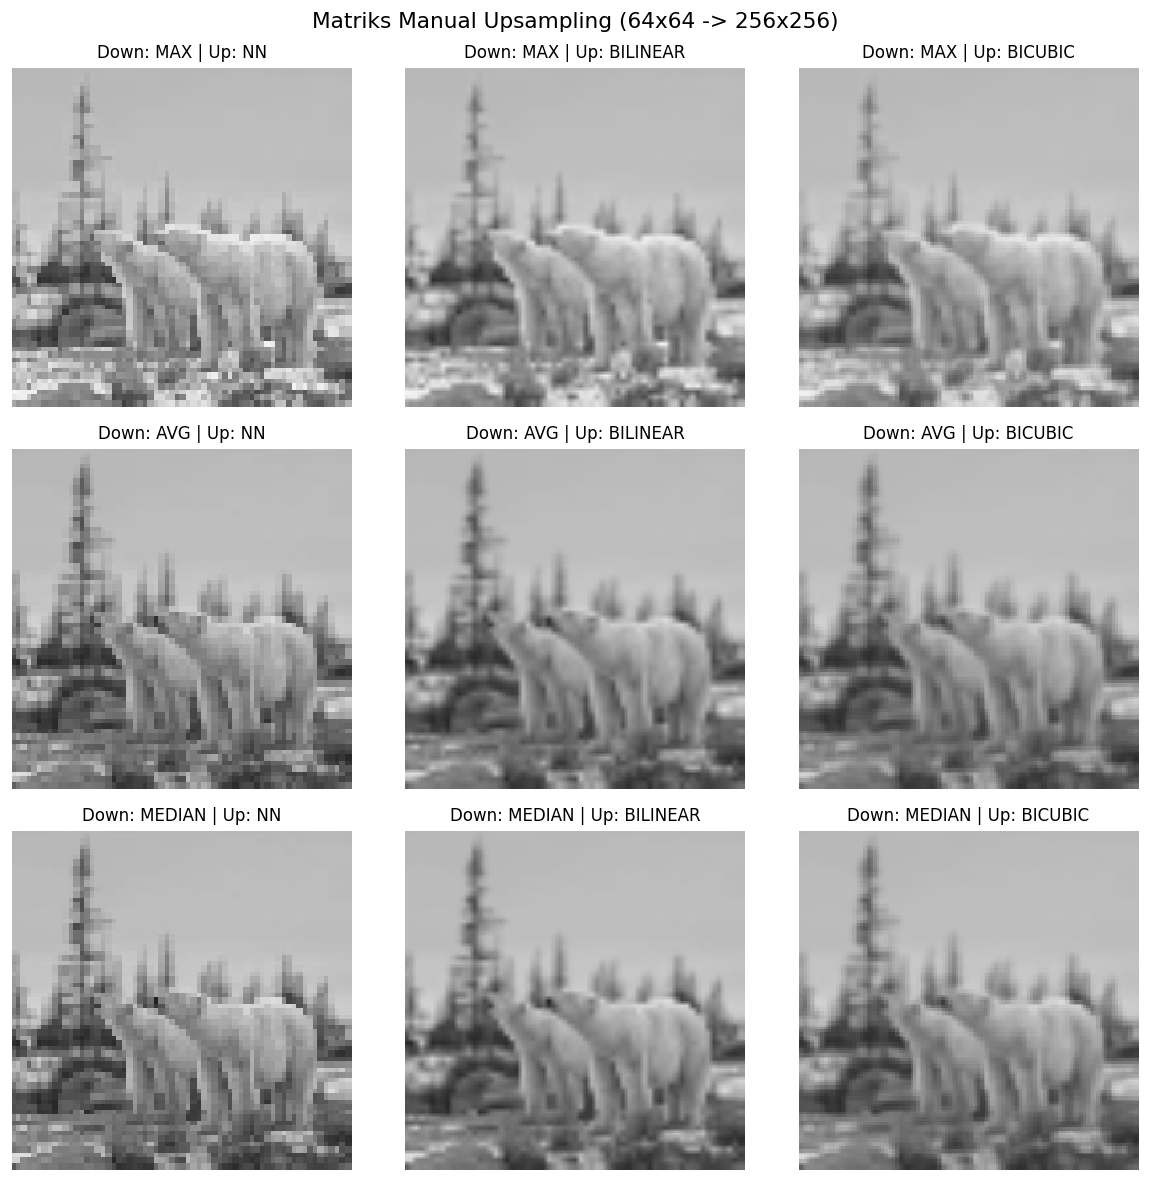

In [ ]:
down_64 = {m: manual_downsampling(sample_img, target_size=64, mode=m) for m in modes}
up_methods = ['nn', 'bilinear', 'bicubic']

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for r, d_mode in enumerate(modes):
    for c, u_method in enumerate(up_methods):
        # rekonstruksi manual dari 64x64 kembali ke dimensi ground truth 256x256
        recon = manual_upsampling(down_64[d_mode], target_size=256, method=u_method)

        ax = axes[r, c]
        ax.imshow(recon, interpolation='nearest', vmin=0, vmax=255)
        ax.set_title(f"Down: {d_mode.upper()} | Up: {u_method.upper()}", fontsize=10)
        ax.axis('off')

plt.suptitle("Matriks Manual Upsampling (64x64 -> 256x256)", fontsize=13)
plt.tight_layout()
plt.show()


# 8. Visualisasi Upsampling

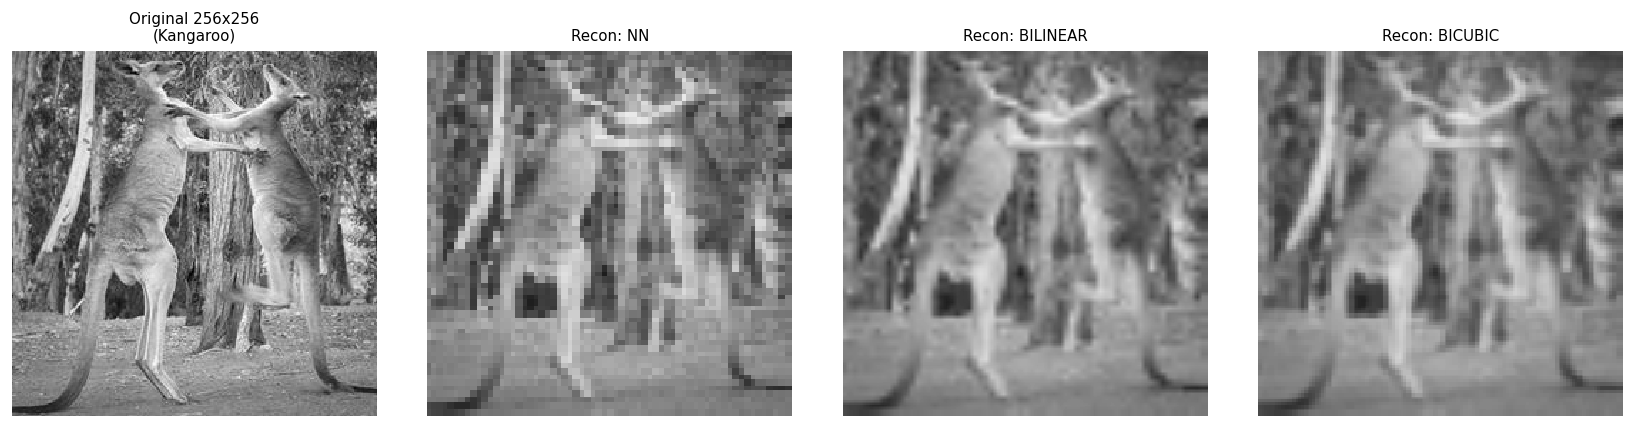

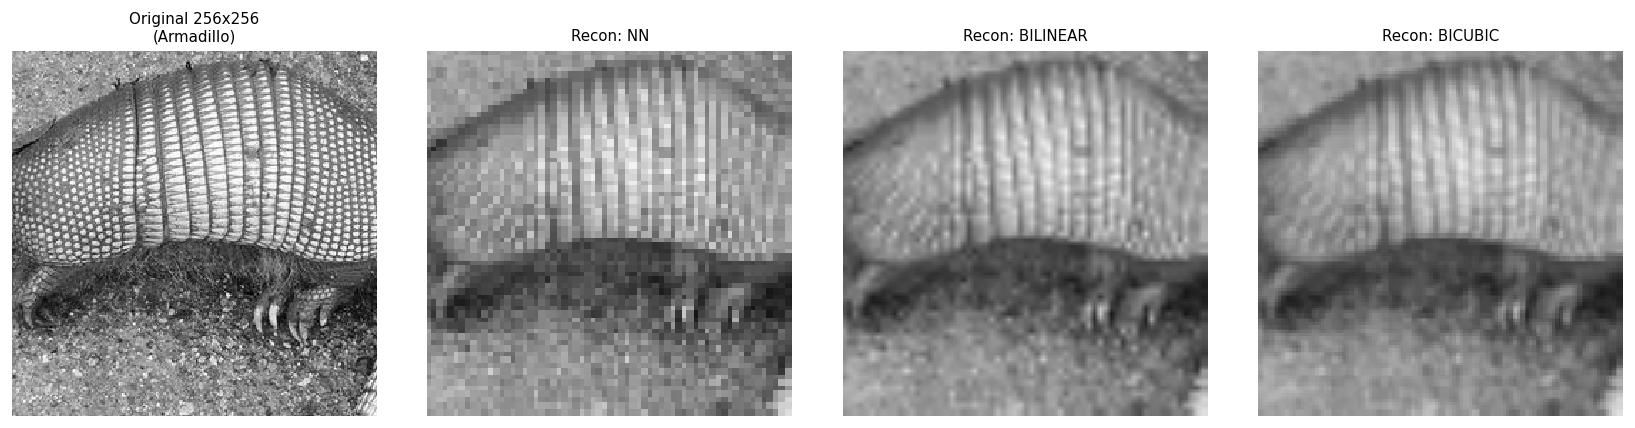

In [74]:
test_images = [("image2", "Kangaroo"), ("image1", "Armadillo")]

for img_key, img_name in test_images:
  current_img = images[img_key]
  fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

  # citra asli
  axes[0].imshow(current_img, interpolation='nearest', vmin=0, vmax=255)
  axes[0].set_title(f"Original 256x256\n({img_name})", fontsize=9)
  axes[0].axis('off')

  # ambil downsample bottleneck 64x64 (Average Pooling)
  down_sample = manual_downsampling(current_img, target_size=64, mode='avg')

  # Rekonstruksi dengan ketiga metode interpolasi
  for idx, u_method in enumerate(['nn', 'bilinear', 'bicubic']):
    recon_img = manual_upsampling(down_sample, target_size=256, method=u_method)
    axes[idx + 1].imshow(recon_img, interpolation='nearest', vmin=0, vmax=255)
    axes[idx + 1].set_title(f"Recon: {u_method.upper()}", fontsize=9)
    axes[idx + 1].axis('off')

  plt.tight_layout()
  plt.show()